<a href="https://colab.research.google.com/github/TNTD-dev/cs114-crop-recommendation/blob/main/notebooks/%5BCS114%5D_Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Environment Setup

In [29]:
# Import thư viện cần thiết
import os
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Đặt seed để đảm bảo kết quả nhất quán giữa các lần chạy
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Seed: {SEED}")


Seed: 42


## 2.Data Processing

In [30]:
# https://drive.google.com/file/d/1ufSkL10inOGqyIYyeIyhRtl1veyLL7QQ/view?usp=sharing
!gdown 1ufSkL10inOGqyIYyeIyhRtl1veyLL7QQ


Downloading...
From: https://drive.google.com/uc?id=1ufSkL10inOGqyIYyeIyhRtl1veyLL7QQ
To: /content/dataset.zip
100% 226k/226k [00:00<00:00, 102MB/s]


In [31]:
!unzip dataset.zip


Archive:  dataset.zip
replace splits/fe_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: splits/fe_train.csv     
  inflating: splits/raw_test.csv     
  inflating: splits/fe_val.csv       
  inflating: splits/raw_train.csv    
  inflating: splits/fe_test.csv      
  inflating: splits/raw_val.csv      


In [32]:
def read_csv(file_path):
    df = pd.read_csv(file_path)
    display(df.head())

    X = df.drop("label", axis=1)
    y = df["label"]
    display(y.value_counts())

    print("Shape df: ", df.shape)
    print("Shape X: ", X.shape)
    print("Shape y: ", y.shape)

    return X, y


### 2.1 Original Dataset

In [33]:
X_train, y_train = read_csv("splits/raw_train.csv")


,N,P,K,temperature,humidity,ph,rainfall,label
0,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440,orange
1,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677,grapes
2,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001,kidneybeans
3,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744,mothbeans
4,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941,orange


,count
label,
orange,80
grapes,80
kidneybeans,80
mothbeans,80
cotton,80
banana,80
lentil,80
mungbean,80
coffee,80


Shape df:  (1760, 8)
Shape X:  (1760, 7)
Shape y:  (1760,)


In [34]:
X_val, y_val = read_csv("splits/raw_val.csv")


,N,P,K,temperature,humidity,ph,rainfall,label
0,1.151956,-1.012190,0.036628,0.850810,0.979283,-0.031974,-1.438846,muskmelon
1,-0.584704,-0.951470,-0.160633,-0.390517,0.822281,-0.419792,0.076979,pomegranate
2,-0.286216,-0.981830,-0.791866,1.830553,0.963498,1.206705,-0.022936,orange
3,-1.154546,2.236312,2.916631,0.279242,0.527697,-0.817973,-0.591064,grapes
4,-0.638975,0.171844,-0.555154,0.472534,-0.844341,-2.651279,-1.226687,mothbeans


,count
label,
muskmelon,10
pomegranate,10
orange,10
grapes,10
mothbeans,10
rice,10
apple,10
watermelon,10
coffee,10


Shape df:  (220, 8)
Shape X:  (220, 7)
Shape y:  (220,)


In [35]:
X_test, y_test = read_csv("splits/raw_test.csv")


,N,P,K,temperature,humidity,ph,rainfall,label
0,-0.856057,-1.103269,-0.180359,-0.174161,0.634989,0.325347,0.142372,pomegranate
1,-0.367622,-0.131755,-0.456523,0.847646,0.648144,-0.074541,-1.128850,mungbean
2,0.039408,0.505802,-0.634058,1.586781,-0.216058,1.354904,-0.657118,blackgram
3,-0.449028,2.630990,2.956083,-0.768910,0.988723,-0.922172,0.213299,apple
4,-1.100275,-1.467587,-0.851044,-0.865604,0.895047,1.716347,0.173379,orange


,count
label,
pomegranate,10
mungbean,10
blackgram,10
apple,10
orange,10
jute,10
pigeonpeas,10
grapes,10
mothbeans,10


Shape df:  (220, 8)
Shape X:  (220, 7)
Shape y:  (220,)


### 2.2 Feature Engineering Dataset

In [36]:
X_train_fe, y_train_fe = read_csv("splits/fe_train.csv")


,humidity,K,rainfall,NPK_mean,P,THI,N,label
0,0.924395,-0.673510,0.199440,-1.499135,-1.072910,1.263240,-1.371628,orange
1,0.426613,3.015261,-0.643677,2.247744,2.084513,0.772089,-1.127411,grapes
2,-2.186291,-0.476250,0.694001,-0.574905,0.536162,-1.952700,-1.073140,kidneybeans
3,-0.459237,-0.594606,-1.231744,-0.724780,-0.465713,-0.344523,-0.340487,mothbeans
4,0.915842,-0.791866,0.289941,-1.424197,-1.255069,-0.990602,-0.883193,orange


,count
label,
orange,80
grapes,80
kidneybeans,80
mothbeans,80
cotton,80
banana,80
lentil,80
mungbean,80
coffee,80


Shape df:  (1760, 8)
Shape X:  (1760, 7)
Shape y:  (1760,)


In [37]:
X_val_fe, y_val_fe = read_csv("splits/fe_val.csv")


,humidity,K,rainfall,NPK_mean,P,THI,N,label
0,0.979283,0.036628,-1.438846,0.137002,-1.012190,1.336179,1.151956,muskmelon
1,0.822281,-0.160633,0.076979,-0.762248,-0.951470,0.381756,-0.584704,pomegranate
2,0.963498,-0.791866,-0.022936,-1.037020,-0.981830,1.979163,-0.286216,orange
3,0.527697,2.916631,-0.591064,2.235254,2.236312,0.563831,-1.154546,grapes
4,-0.844341,-0.555154,-1.226687,-0.574905,0.171844,-0.538589,-0.638975,mothbeans


,count
label,
muskmelon,10
pomegranate,10
orange,10
grapes,10
mothbeans,10
rice,10
apple,10
watermelon,10
coffee,10


Shape df:  (220, 8)
Shape X:  (220, 7)
Shape y:  (220,)


In [38]:
X_test_fe, y_test_fe = read_csv("splits/fe_test.csv")


,humidity,K,rainfall,NPK_mean,P,THI,N,label
0,0.634989,-0.180359,0.142372,-0.962082,-1.103269,0.375286,-0.856057,pomegranate
1,0.648144,-0.456523,-1.128850,-0.512457,-0.131755,1.019918,-0.367622,mungbean
2,-0.216058,-0.634058,-0.657118,-0.175238,0.505802,0.556072,0.039408,blackgram
3,0.988723,2.956083,0.213299,2.747328,2.630990,0.250801,-0.449028,apple
4,0.895047,-0.851044,0.173379,-1.649010,-1.467587,0.122456,-1.100275,orange


,count
label,
pomegranate,10
mungbean,10
blackgram,10
apple,10
orange,10
jute,10
pigeonpeas,10
grapes,10
mothbeans,10


Shape df:  (220, 8)
Shape X:  (220, 7)
Shape y:  (220,)


## 3.Naive Bayes Classifier

In [39]:
def evaluate_val(X_train, y_train, X_val, y_val):
    # Huấn luyện Naive Bayes
    nbc_model = GaussianNB()
    nbc_model.fit(X_train, y_train)

    # Dự đoán và đánh giá trên tập val
    nb_pred = nbc_model.predict(X_val)
    nb_accuracy = accuracy_score(y_val, nb_pred)

    print(f"Độ chính xác Naive Bayes: {nb_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, nb_pred))
    return nbc_model, nb_accuracy


def evaluate_test(nbc_model, X_test, y_test):
    # Dự đoán và đánh giá trên tập test
    nb_test_pred = nbc_model.predict(X_test)
    nb_test_accuracy = accuracy_score(y_test, nb_test_pred)
    print(f"Độ chính xác Naive Bayes trên tập test: {nb_test_accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, nb_test_pred))
    return nb_test_accuracy


### 3.1 NBC on Original Dataset

In [40]:
# Huấn luyện và đánh giá với dữ liệu gốc
model, accuracy = evaluate_val(X_train, y_train, X_val, y_val)
test_accuracy = evaluate_test(model, X_test, y_test)


Độ chính xác Naive Bayes: 1.0000

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        10
      banana       1.00      1.00      1.00        10
   blackgram       1.00      1.00      1.00        10
    chickpea       1.00      1.00      1.00        10
     coconut       1.00      1.00      1.00        10
      coffee       1.00      1.00      1.00        10
      cotton       1.00      1.00      1.00        10
      grapes       1.00      1.00      1.00        10
        jute       1.00      1.00      1.00        10
 kidneybeans       1.00      1.00      1.00        10
      lentil       1.00      1.00      1.00        10
       maize       1.00      1.00      1.00        10
       mango       1.00      1.00      1.00        10
   mothbeans       1.00      1.00      1.00        10
    mungbean       1.00      1.00      1.00        10
   muskmelon       1.00      1.00      1.00        10
      orange       1.00 

### 3.2 NBC on Feature Engineering Dataset

In [41]:
# Huấn luyện và đánh giá với kỹ thuật tạo đặc trưng
model_fe, accuracy_fe = evaluate_val(X_train_fe, y_train_fe, X_val_fe, y_val_fe)
test_accuracy_fe = evaluate_test(model_fe, X_test_fe, y_test_fe)


Độ chính xác Naive Bayes: 0.9909

Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        10
      banana       1.00      1.00      1.00        10
   blackgram       1.00      1.00      1.00        10
    chickpea       1.00      1.00      1.00        10
     coconut       1.00      1.00      1.00        10
      coffee       1.00      1.00      1.00        10
      cotton       0.91      1.00      0.95        10
      grapes       1.00      1.00      1.00        10
        jute       1.00      0.90      0.95        10
 kidneybeans       1.00      1.00      1.00        10
      lentil       1.00      1.00      1.00        10
       maize       1.00      0.90      0.95        10
       mango       1.00      1.00      1.00        10
   mothbeans       1.00      1.00      1.00        10
    mungbean       1.00      1.00      1.00        10
   muskmelon       1.00      1.00      1.00        10
      orange       1.00 

## 4.Result Visualization

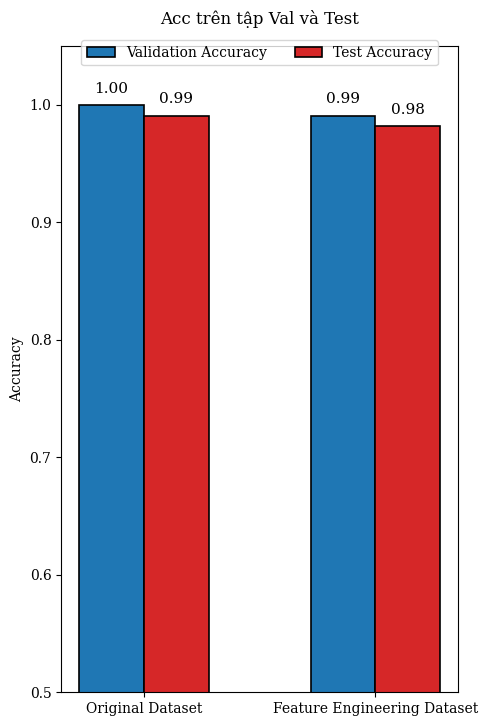

In [49]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Serif'

labels = ['Original Dataset', 'Feature Engineering Dataset']
val_accs  = [accuracy, accuracy_fe]
test_accs = [test_accuracy, test_accuracy_fe]

x = np.arange(len(labels))
width = 0.28

fig, ax = plt.subplots(figsize=(5, 8))

rects1 = ax.bar(
    x - width/2, val_accs, width,
    label='Validation Accuracy',
    color='tab:blue', edgecolor='black', linewidth=1.2
)
rects2 = ax.bar(
    x + width/2, test_accs, width,
    label='Test Accuracy',
    color='tab:red', edgecolor='black', linewidth=1.2
)

# tăng khoảng trống phía trên
ax.set_ylim(0.5, 1.05)

ax.set_ylabel('Accuracy')
ax.set_title('Acc trên tập Val và Test', pad=16)
ax.set_xticks(x)
ax.set_xticklabels(labels)

# đẩy legend lên trên title một chút hoặc đặt gọn bên trong
ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.02), frameon=True)

def autolabel(rects, offset=0.008):
    for rect in rects:
        h = rect.get_height()
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            h + offset,
            f'{h:.2f}',
            ha='center',
            va='bottom',
            fontsize=11,
            clip_on=False
        )

autolabel(rects1)
autolabel(rects2)

# chừa thêm mép trên
plt.tight_layout(rect=[0, 0, 1, 0.92])

fig.savefig("accuracy_comparison.png", dpi=300, bbox_inches="tight")
fig.savefig("accuracy_comparison.pdf", bbox_inches="tight")
plt.show()